In [1]:
from pathlib import Path
import os

# Detect Colab
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Text_Mining_Project")
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)



Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Text_Mining_Project
RAW_DIR: /content/drive/MyDrive/Text_Mining_Project/data/raw
PROCESSED_DIR: /content/drive/MyDrive/Text_Mining_Project/data/processed


This cell imports all the Python libraries required for:

*   data loading and manipulation
*   clustering algorithms
*   dimensionality reduction
*   clustering evaluation metrics
*   visualization

In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    v_measure_score
)


This cell defines the paths to all files generated during the text representation phase:

- the preprocessed dataframe
- the TF-IDF document-term matrix
- the TF-IDF vectorizer
- the sentence embeddings

In [3]:
# Dataframe preprocessato
df_path_1 = PROCESSED_DIR / "df_bbc_preprocessed_split.pkl"
df_path_2 = PROCESSED_DIR / "df_bbc_preprocessed.pkl"

# Rappresentazioni già salvate
tfidf_all_path = PROCESSED_DIR / "X_all_tfidf.joblib"
tfidf_vec_all_path = PROCESSED_DIR / "tfidf_vectorizer_all.joblib"
emb_all_path = PROCESSED_DIR / "embeddings_all.npy"

print("df_path_1 exists:", df_path_1.exists())
print("df_path_2 exists:", df_path_2.exists())
print("X_all_tfidf exists:", tfidf_all_path.exists())
print("tfidf_vectorizer_all exists:", tfidf_vec_all_path.exists())
print("embeddings_all exists:", emb_all_path.exists())


df_path_1 exists: True
df_path_2 exists: True
X_all_tfidf exists: True
tfidf_vectorizer_all exists: True
embeddings_all exists: True


This cell loads the preprocessed dataset and extracts the document labels, which are used as ground truth for external clustering evaluation.

In [4]:
if df_path_1.exists():
    df = pd.read_pickle(df_path_1)
elif df_path_2.exists():
    df = pd.read_pickle(df_path_2)
else:
    raise FileNotFoundError(f"Non trovo il dataframe preprocessato in:\n- {df_path_1}\n- {df_path_2}")

required_cols = ["clean_text_bow", "clean_text_bert", "label"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Nel dataframe mancano colonne richieste: {missing}")

y_true = df["label"].astype(str).values

print("DF shape:", df.shape)
print("Label distribution:\n", pd.Series(y_true).value_counts())
df.head(3)


DF shape: (2232, 9)
Label distribution:
 business         517
sport            511
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


,text,label,length,clean_text_bow,clean_text_bert,bow_length,bert_length,is_train,is_test
0,Swap offer for pirated Windows XP\n\nComputer ...,tech,353,swap offer pirated window xp computer giant mi...,Swap offer for pirated Windows XP Computer gia...,212,353,True,False
1,DS aims to touch gamers\n\nThe mobile gaming i...,tech,567,ds aim touch gamer mobile gaming industry set ...,DS aims to touch gamers The mobile gaming indu...,318,567,True,False
2,Digital guru floats sub-$100 PC\n\nNicholas Ne...,tech,464,digital guru float sub pc nicholas negroponte ...,Digital guru floats sub-$100 PC Nicholas Negro...,240,464,False,True


This cell loads the two document representations used in the experiments:

- TF-IDF vectors (sparse, lexical representation),
- Sentence embeddings (dense, semantic representation).

Embeddings are additionally normalized to make cosine-based similarity measures more reliable.

In [5]:
# TF-IDF (sparse)
if tfidf_all_path.exists() and tfidf_vec_all_path.exists():
    X_tfidf = joblib.load(tfidf_all_path)
    tfidf_vec = joblib.load(tfidf_vec_all_path)
    print("Loaded TF-IDF:", X_tfidf.shape)
else:
    raise FileNotFoundError("Mancano X_all_tfidf.joblib o tfidf_vectorizer_all.joblib. Esegui Notebook_3 prima.")

# Embeddings (dense)
if emb_all_path.exists():
    X_emb = np.load(emb_all_path)
    print("Loaded embeddings:", X_emb.shape)
else:
    raise FileNotFoundError("Manca embeddings_all.npy. Esegui Notebook_3 prima.")

# Normalizzazione per cosine (consigliata)
X_emb_norm = normalize(X_emb)


Loaded TF-IDF: (2232, 6985)
Loaded embeddings: (2232, 384)


This cell defines a set of evaluation functions used to assess clustering quality:

- Silhouette Score (internal evaluation)
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)
- V-measure
- Purity
- Macro F1-score with cluster-to-label mapping.

In [6]:
from sklearn.metrics import f1_score

def purity_score(y_true, y_pred):
    # Purity = sum over clusters of max class count / N
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        true_labels = y_true[idx]
        counts = pd.Series(true_labels).value_counts()
        total += counts.iloc[0]
    return total / len(y_true)

def cluster_to_label_mapping(y_true, y_pred):
    """
    Mappa ogni cluster alla label vera più frequente in quel cluster.
    Ritorna y_pred_mapped (etichette "simulate") e il mapping dict.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mapping = {}
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        majority_label = pd.Series(y_true[idx]).value_counts().idxmax()
        mapping[c] = majority_label
    y_mapped = np.array([mapping[c] for c in y_pred])
    return y_mapped, mapping

def evaluate_all_metrics(X, y_true, y_pred, silhouette_metric="cosine"):
    out = {}
    # Silhouette (interna)
    try:
        out["silhouette"] = float(silhouette_score(X, y_pred, metric=silhouette_metric))
    except Exception:
        out["silhouette"] = np.nan

    # Esterne (ground truth)
    out["ARI"] = float(adjusted_rand_score(y_true, y_pred))
    out["NMI"] = float(normalized_mutual_info_score(y_true, y_pred))
    out["V_measure"] = float(v_measure_score(y_true, y_pred))

    # Purity
    out["purity"] = float(purity_score(y_true, y_pred))

    # F1 macro via mapping cluster->label
    y_mapped, mapping = cluster_to_label_mapping(y_true, y_pred)
    out["F1_macro_mapped"] = float(f1_score(y_true, y_mapped, average="macro"))
    out["mapping"] = mapping
    return out


This cell evaluates different values of k (number of clusters) using silhouette analysis for both:

- TF-IDF representations
- sentence embeddings

A silhouette-vs-k plot is produced for each representation.

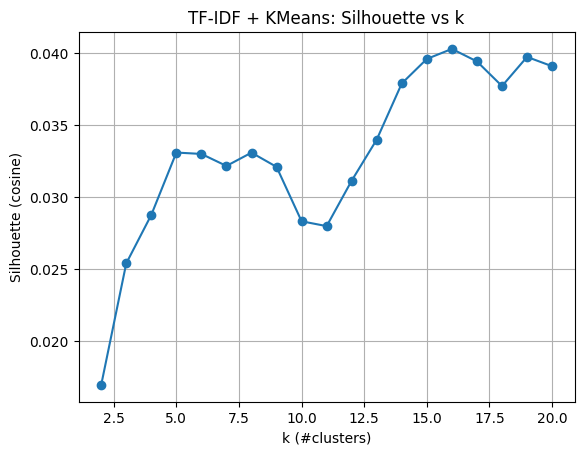

Best k TF-IDF: 16


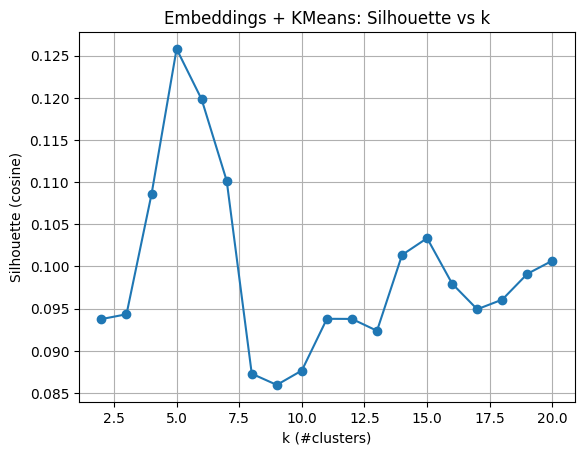

Best k Embeddings: 5


In [7]:
RANDOM_STATE = 42
k_values = list(range(2, 21))

def silhouette_sweep_kmeans(X, k_values, metric="cosine"):
    scores = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(X)
        try:
            s = silhouette_score(X, labels, metric=metric)
        except Exception:
            s = np.nan
        scores.append(s)
    return np.array(scores)

# Sweep TF-IDF (cosine)
sil_tfidf = silhouette_sweep_kmeans(X_tfidf, k_values, metric="cosine")
best_k_tfidf = k_values[int(np.nanargmax(sil_tfidf))]

plt.figure()
plt.plot(k_values, sil_tfidf, marker="o")
plt.xlabel("k (#clusters)")
plt.ylabel("Silhouette (cosine)")
plt.title("TF-IDF + KMeans: Silhouette vs k")
plt.grid(True)
plt.show()

print("Best k TF-IDF:", best_k_tfidf)

# Sweep Embeddings (cosine)
sil_emb = silhouette_sweep_kmeans(X_emb_norm, k_values, metric="cosine")
best_k_emb = k_values[int(np.nanargmax(sil_emb))]

plt.figure()
plt.plot(k_values, sil_emb, marker="o")
plt.xlabel("k (#clusters)")
plt.ylabel("Silhouette (cosine)")
plt.title("Embeddings + KMeans: Silhouette vs k")
plt.grid(True)
plt.show()

print("Best k Embeddings:", best_k_emb)


This cell performs the core clustering experiments by combining:

- two text representations (TF-IDF, embeddings)
- two clustering algorithms (KMeans, Agglomerative Clustering).

For TF-IDF, dimensionality reduction via Truncated SVD is applied before hierarchical clustering to ensure computational feasibility.

All clustering configurations are evaluated using the full set of metrics defined earlier, and results are summarized in a comparison table.

In [8]:
results = []

# 1) TF-IDF + KMeans
km_tfidf = KMeans(n_clusters=best_k_tfidf, random_state=RANDOM_STATE, n_init="auto")
labels_km_tfidf = km_tfidf.fit_predict(X_tfidf)
m1 = evaluate_all_metrics(X_tfidf, y_true, labels_km_tfidf, silhouette_metric="cosine")
results.append({"model": "TF-IDF + KMeans", "k": best_k_tfidf, **{k:v for k,v in m1.items() if k!="mapping"}})

# 2) TF-IDF -> SVD -> Agglomerative (ward)
svd = TruncatedSVD(n_components=200, random_state=RANDOM_STATE)
X_tfidf_svd = svd.fit_transform(X_tfidf)
agg_tfidf = AgglomerativeClustering(n_clusters=best_k_tfidf, metric="euclidean", linkage="ward")
labels_agg_tfidf = agg_tfidf.fit_predict(X_tfidf_svd)
m2 = evaluate_all_metrics(X_tfidf_svd, y_true, labels_agg_tfidf, silhouette_metric="euclidean")
results.append({"model": "TF-IDF(SVD200) + Agglomerative(ward)", "k": best_k_tfidf, **{k:v for k,v in m2.items() if k!="mapping"}})

# 3) Embeddings + KMeans
km_emb = KMeans(n_clusters=best_k_emb, random_state=RANDOM_STATE, n_init="auto")
labels_km_emb = km_emb.fit_predict(X_emb_norm)
m3 = evaluate_all_metrics(X_emb_norm, y_true, labels_km_emb, silhouette_metric="cosine")
results.append({"model": "Embeddings + KMeans", "k": best_k_emb, **{k:v for k,v in m3.items() if k!="mapping"}})

# 4) Embeddings + Agglomerative (cosine + average)
agg_emb = AgglomerativeClustering(n_clusters=best_k_emb, metric="cosine", linkage="average")
labels_agg_emb = agg_emb.fit_predict(X_emb_norm)
m4 = evaluate_all_metrics(X_emb_norm, y_true, labels_agg_emb, silhouette_metric="cosine")
results.append({"model": "Embeddings + Agglomerative(cosine,avg)", "k": best_k_emb, **{k:v for k,v in m4.items() if k!="mapping"}})

res_df = pd.DataFrame(results)
res_df = res_df.sort_values(by=["ARI", "NMI", "silhouette"], ascending=False)

display(res_df)


,model,k,silhouette,ARI,NMI,V_measure,purity,F1_macro_mapped
2,Embeddings + KMeans,5,0.125800,0.903473,0.874429,0.874429,0.959229,0.958220
3,"Embeddings + Agglomerative(cosine,avg)",5,0.079821,0.499457,0.603504,0.603504,0.604839,0.476297
1,TF-IDF(SVD200) + Agglomerative(ward),16,0.058099,0.374230,0.566989,0.566989,0.851254,0.846131
0,TF-IDF + KMeans,16,0.040268,0.275622,0.535511,0.535511,0.793907,0.800028


This cell visualizes clustering results using a 2D PCA projection of sentence embeddings, with points colored according to predicted cluster assignments.

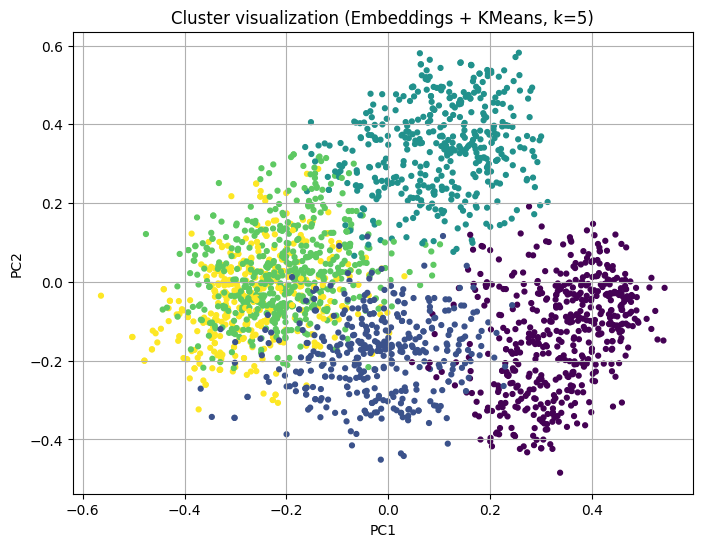

In [9]:
# Riduzione a 2 dimensioni per visualizzazione (PCA)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis = pca2.fit_transform(X_emb_norm)

plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels_km_emb, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Cluster visualization (Embeddings + KMeans, k={best_k_emb})")
plt.grid(True)
plt.show()


This cell visualizes the same 2D embedding space twice:

- once colored by predicted cluster assignments
- once colored by true class labels.

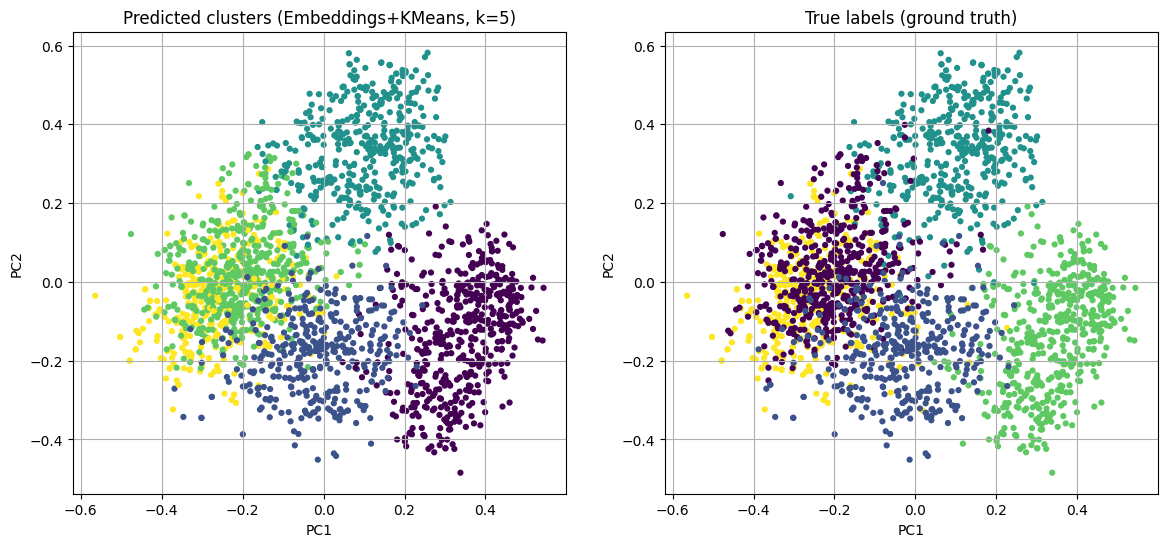

Label mapping used for plot: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}


In [10]:
# Encoding delle label vere per colorarle
unique_labels = sorted(pd.Series(y_true).unique())
label_to_id = {lab:i for i, lab in enumerate(unique_labels)}
y_ids = np.array([label_to_id[lab] for lab in y_true])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels_km_emb, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Predicted clusters (Embeddings+KMeans, k={best_k_emb})")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_ids, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("True labels (ground truth)")
plt.grid(True)

plt.show()

print("Label mapping used for plot:", label_to_id)


This table shows how documents from each true BBC category are distributed across the predicted clusters.
Row-normalized values highlight how well each semantic class is captured by a dominant cluster.

In [15]:
# Cluster vs True label table (crosstab)

crosstab = pd.crosstab(
    pd.Series(y_true, name="True label"),
    pd.Series(labels_km_emb, name=f"Cluster (k={best_k_emb})")
)

print("CROSSTAB: True labels vs Predicted clusters (Embeddings + KMeans)")
display(crosstab)

print("\nCROSSTAB (row-normalized, percentages):")
display((crosstab.div(crosstab.sum(axis=1), axis=0) * 100).round(2))


CROSSTAB: True labels vs Predicted clusters (Embeddings + KMeans)


Cluster (k=5),0,1,2,3,4
True label,,,,,
business,2,1,13,483,18
entertainment,0,366,3,3,14
politics,3,1,397,12,4
sport,507,3,1,0,0
tech,3,8,0,2,388



CROSSTAB (row-normalized, percentages):


Cluster (k=5),0,1,2,3,4
True label,,,,,
business,0.39,0.19,2.51,93.42,3.48
entertainment,0.00,94.82,0.78,0.78,3.63
politics,0.72,0.24,95.20,2.88,0.96
sport,99.22,0.59,0.20,0.00,0.00
tech,0.75,2.00,0.00,0.50,96.76


The distribution of documents across clusters is shown to assess balance and detect potential dominance of specific clusters.
Well-balanced clusters generally indicate a more stable and interpretable clustering solution.

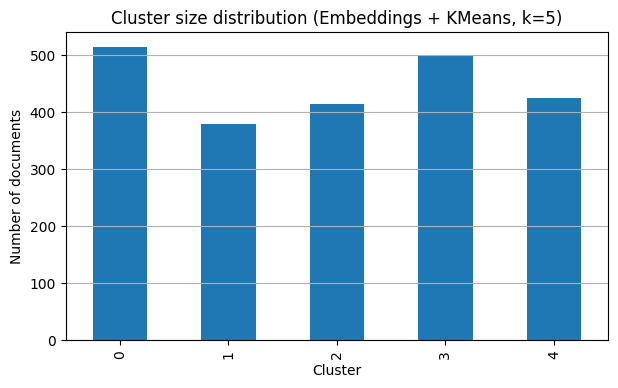

Cluster sizes:


,count
0,515
1,379
2,414
3,500
4,424


In [16]:

# EXTRA 3) Cluster size distribution

cluster_sizes = pd.Series(labels_km_emb).value_counts().sort_index()

plt.figure(figsize=(7, 4))
cluster_sizes.plot(kind="bar")
plt.title(f"Cluster size distribution (Embeddings + KMeans, k={best_k_emb})")
plt.xlabel("Cluster")
plt.ylabel("Number of documents")
plt.grid(True, axis="y")
plt.show()

print("Cluster sizes:")
display(cluster_sizes.to_frame(name="count"))


This cell extracts and prints the most representative terms for each cluster obtained with TF-IDF + KMeans, based on centroid weights.

In [11]:
def print_top_terms_per_cluster(km_model, vectorizer, topn=10):
    terms = np.array(vectorizer.get_feature_names_out())
    centroids = km_model.cluster_centers_
    for c in range(centroids.shape[0]):
        top_idx = centroids[c].argsort()[::-1][:topn]
        print(f"\nCluster {c}:")
        print(", ".join(terms[top_idx]))

print_top_terms_per_cluster(km_tfidf, tfidf_vec, topn=12)



Cluster 0:
club, chelsea, game, arsenal, league, play, united, liverpool, goal, player, manager, win

Cluster 1:
bn, share, firm, company, profit, sale, market, year, airline, deal, stock, us

Cluster 2:
chart, number, elvis, top, single, box, album, presley, office, film, download, release

Cluster 3:
yukos, oil, russian, gazprom, russia, yugansk, rosneft, crude, price, company, bn, barrel

Cluster 4:
olympic, race, indoor, win, athens, athlete, world, iaaf, champion, kenteris, championship, medal

Cluster 5:
ukip, kilroy, silk, party, mr, election, donation, houston, verita, candidate, mep, hockney

Cluster 6:
mr, labour, election, blair, party, tory, brown, howard, would, tax, minister, chancellor

Cluster 7:
mr, lord, law, eu, court, government, would, police, case, minister, right, legal

Cluster 8:
year, show, open, win, work, people, play, make, world, seed, first, set

Cluster 9:
band, music, album, song, singer, award, pop, record, rock, artist, year, good

Cluster 10:
game, 